In [31]:
import sys
from functools import partial

sys.path.append("../src")
import jax

jax.config.update("jax_platform_name", "cpu")
from jax import config

config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import jit, random, vmap
from matplotlib.ticker import LinearLocator


In [2]:
from configuration.rte1d_settings import get_config
from constraints.continuous1d import (
    MicroMacroPointwiseBoundaryConstraint1D as BC,
)
from constraints.continuous1d import (
    MicroMacroPointwiseInteriorConstraint1D as EQ,
)
from geometry.meshxd_ds import UniformMeshX, UniformMeshXV
from modules.generator import Sample1D
from modules.solution import MicroMacroConstructor1D
from solver.least_square import solve
from utils.integrate import leggauss


In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Mp_rho = rte_config.model.Mp["rho"]
Mp_g = rte_config.model.Mp["g"]
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["rho/g"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
bdy_value = rte_config.model.bdy_cond
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_rho = UniformMeshX(domain=domain, strides=strides)
mesh_g = UniformMeshXV(domain=domain, strides=strides)
# print(f"Mp_rho: {Mp_rho}, Mp_g: {Mp_g} - Jn_rho: {Jn["rho"]}, Jn_g: {Jn["g"]}")

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_v = jnp.split(jnp.array([0.0, 0.0]), 2, axis=0)
params = {}
eq_instance = rte.apply(params, dummy_x, dummy_v)
bc_instance = bc.apply(params, dummy_x, dummy_v)

In [6]:
# (2, Mp_rho*Jn_rho+Mp_g*Jn_g), (Mp_rho*Jn_rho+Mp_g*Jn_g,)
eq_instance.shape, bc_instance.shape

((3, 128), (128,))

In [7]:
def eq_fn(x, v):
    return partial(rte.apply, params)(x, v)


def bc_fn(x, v):
    return partial(bc.apply, params)(x, v)


def rhs_fn(x, v):
    quadratures = leggauss(num_quads)
    q = source_fn(x, v).squeeze()
    avg_q = integrator(source_fn, quadratures, 1)(x)
    return jnp.array([avg_q, (q - avg_q), 0])
    # return jnp.array([avg_q, kn * (q - avg_q), 0])
    # return jnp.array([avg_q, kn * (q - avg_q)])


def integrator(fn, quadratures, argnum):
    pts, ws = quadratures

    def integral_fn(*args):
        args = list(args)
        in_axes_ = [None] * len(args)
        args.insert(argnum, pts)
        in_axes_.insert(argnum, int(0))
        vmap_fns = vmap(fn, in_axes=in_axes_, out_axes=-1)(*args)
        out = jnp.dot(vmap_fns, ws).squeeze()
        return jnp.array(out)

    return integral_fn


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

# vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
#     vmap(jit(eq_fn)),
#     vmap(jit(bc_fn)),
#     vmap(jit(rhs_fn)),
# )

# vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = vmap(eq_fn), vmap(bc_fn), vmap(rhs_fn)

## time
# vmap - 9:11
# vmap+jit - 1:55
# jit+vmap - 1:49

In [8]:
sampler = Sample1D(
    domain=domain, collocation_sizes=collocation_sizes, mode=mode
)
xv_int, xv_bcl, xv_bcr = sampler.pts_int, sampler.pts_left, sampler.pts_right

In [70]:
xv_int[1].shape

(1860, 1)

In [9]:
# Evaluate the functions
bc_left, bc_right = vmap_bc_fn(*xv_bcl), vmap_bc_fn(*xv_bcr)

In [10]:
eq_int = vmap_eq_fn(*xv_int)

In [11]:
rhs_int = vmap_rhs_fn(*xv_int)

In [12]:
print(f"Boundary: {bc_left.shape}, {bc_right.shape}, Interior: {eq_int.shape}")

Boundary: (64, 128), (64, 128), Interior: (1860, 3, 128)


In [13]:
# Save the data
matrix_A = np.concatenate(
    [bc_left, bc_right, eq_int.reshape(-1, num_unknowns)], axis=0
)
vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size = bc_left.shape[0]
vector_b[:bdy_size, 0] = bdy_value["f_l"](xv_bcl[-1])
vector_b[bdy_size : 2 * bdy_size, 0] = bdy_value["f_r"](xv_bcr[-1])
vector_b[2 * bdy_size :, 0] = rhs_int.reshape(-1)
print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (5708, 128), Vector b: (5708, 1)


In [14]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
print(f"Vector U: {vector_U.shape}")

Vector U: (128, 1)


In [15]:
np.linalg.norm(matrix_A @ vector_U - vector_b) / np.linalg.norm(vector_b)

np.float64(1.7714999418452555e-12)

In [16]:
from numpy.linalg import cond

print(f"Condition number: {cond(matrix_A)}")

Condition number: 2.4691620674332037e+18


In [17]:
# data = np.load("../src/data/weights.npz")
# vector_U = data["coefficients"]

In [18]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns,
)
constructor = MicroMacroConstructor1D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [19]:
def approx_fn(x, v):
    return partial(constructor.apply, params)(x, v)

In [20]:
dummy_z = jnp.array([0.7, -0.5])
dummy_x, dummy_v = jnp.split(dummy_z, 2, axis=0)
print(f"f({dummy_z}) = {jit(approx_fn)(dummy_x, dummy_v)}")  # 0.15

f([ 0.7 -0.5]) = 0.3000000000025228


In [21]:
vmap_approx_fn = vmap(approx_fn)

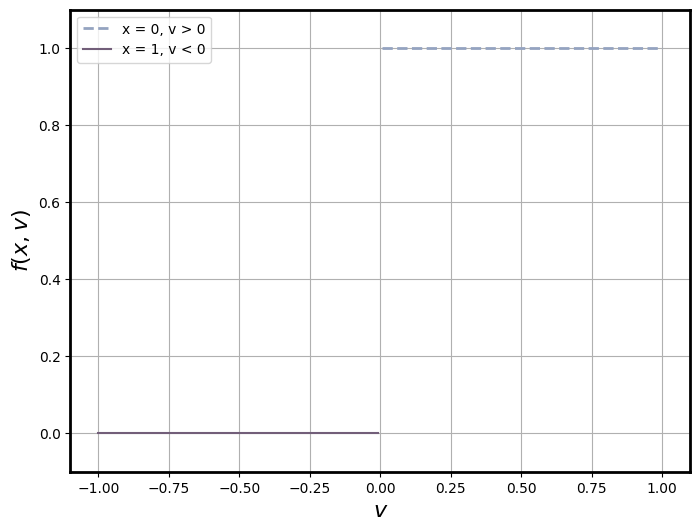

In [22]:
plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
plt.plot(
    xv_bcl[1],
    vmap_approx_fn(*xv_bcl),
    "--",
    color="#94A3C0",
    markersize=10,
    linewidth=2,
    label="x = 0, v > 0",
)
plt.plot(
    xv_bcr[1],
    vmap_approx_fn(*xv_bcr),
    "-",
    color="#725E79",
    label="x = 1, v < 0",
)
plt.ylim(ymin=-0.1, ymax=1.1)
plt.xlabel(r"$v$", fontsize=16)
plt.ylabel(r"$f (x, v)$", fontsize=16)
plt.grid()
plt.legend()
# line width of four axises
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)
# plt.savefig("rte_approx_BC.png", dpi=300)
plt.show()
plt.close()

In [57]:
# data = np.load(f"../src/data/rte1d_ex1_ref_{kn:.1e}.npz")
# mesh_x, mesh_v, F = data["mesh_x"], data["mesh_v"], data["F"]
# X, V = np.meshgrid(mesh_x, mesh_v)
# XV = np.stack([X, V], axis=-1)
# F_hat = vmap_approx_fn(*np.split(XV.reshape(-1, 2), 2, axis=1)).reshape(
#     X.shape
# )
mesh_x = jnp.linspace(domain["x"][0], domain["x"][1], 1024)
mesh_v = jnp.linspace(domain["v"][0], domain["v"][1], 2048)
F = 1 - mesh_x
F = jnp.tile(F[..., None], (1, mesh_v.shape[0]))

X, V = jnp.meshgrid(mesh_x, mesh_v, indexing="ij")
XV = np.stack([X, V], axis=-1)
F_hat = vmap_approx_fn(*np.split(XV.reshape(-1, 2), 2, axis=1))
F_hat = F_hat.reshape(X.shape)
F.shape, F_hat.shape

((1024, 2048), (1024, 2048))

In [ ]:
# np.savez(
#     f"../src/data/aprfm1d_solutions_{kn:.1e}.npz", X=X, V=V, F=F, F_hat=F_hat
# )

In [56]:
jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F)

Array(1.59937885e-11, dtype=float64)

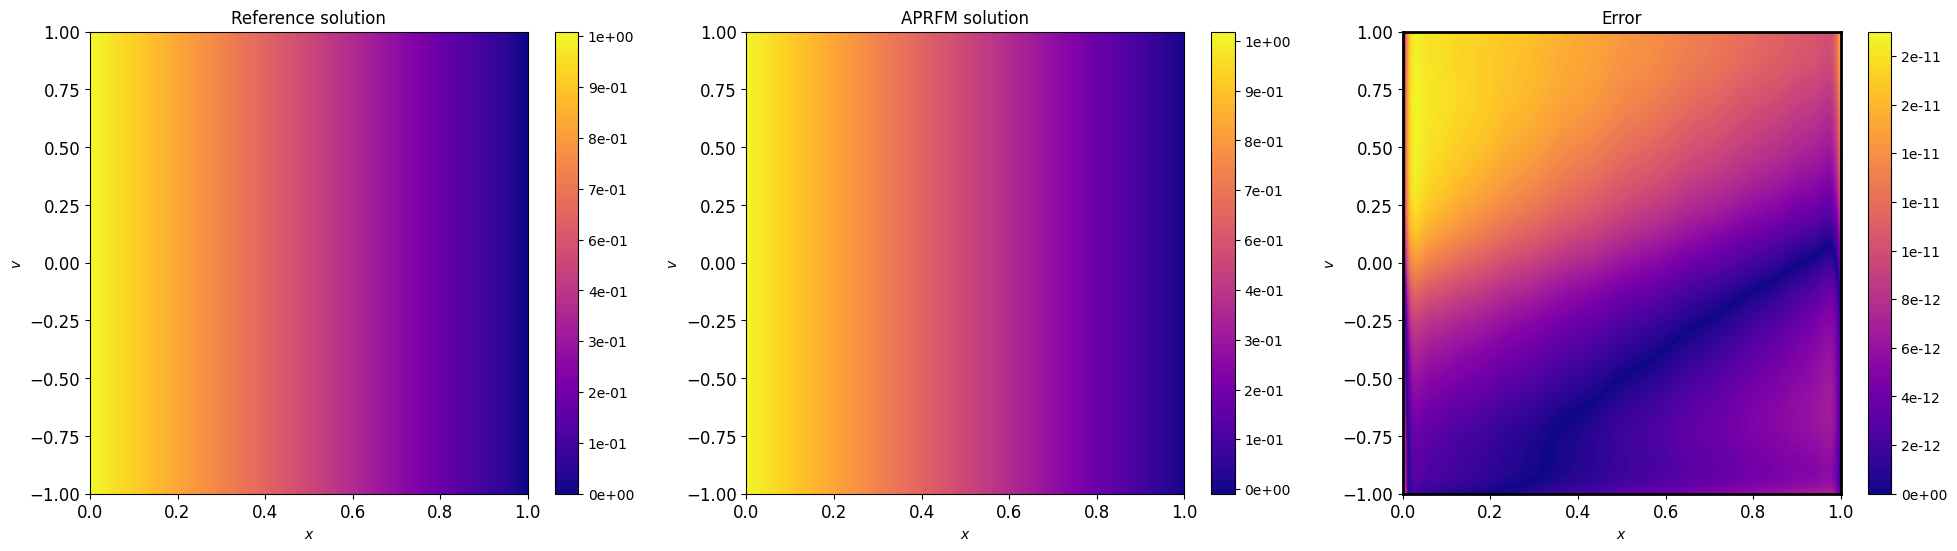

In [58]:
plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
plt.contourf(X, V, F, 100, cmap="plasma")
# font size and type
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x$")
plt.ylabel(r"$v$")
plt.colorbar(format="%.0e")
plt.title("Reference solution")

ax2 = plt.subplot(1, 3, 2)
plt.contourf(X, V, F_hat, 100, cmap="plasma")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x$")
plt.ylabel(r"$v$")
plt.colorbar(format="%.0e")
plt.title("APRFM solution")

ax3 = plt.subplot(1, 3, 3)
plt.contourf(X, V, np.abs(F - F_hat), 100, cmap="plasma")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x$")
plt.ylabel(r"$v$")
plt.colorbar(format="%.0e")
plt.title("Error")
# line width of four axises
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)

plt.show()
plt.close()

cannot import name 'docstring' from 'matplotlib' (/home/sheny-y23/.local/lib/python3.10/site-packages/matplotlib/__init__.py)


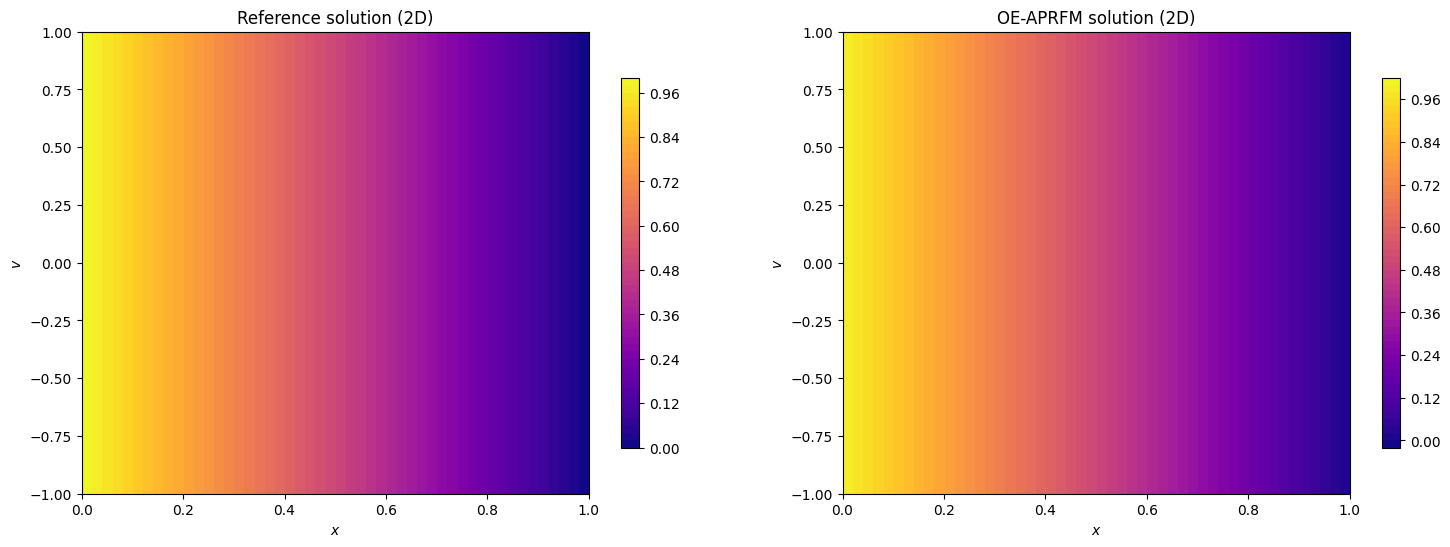

In [59]:
# 3D 可用则画曲面，失败则退化为 2D 等高线
try:
    import mpl_toolkits.mplot3d  # 注册 3D 投影

    _has_3d = True
except Exception as exc:
    print("Warning: 3D backend unavailable, fallback to 2D contour.")
    print(exc)
    _has_3d = False

if _has_3d:
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    surf1 = ax1.plot_surface(
        X, V, F, cmap="plasma", linewidth=0, antialiased=False
    )
    ax1.set_xlabel(r"$x$")
    ax1.set_ylabel(r"$v$")
    ax1.zaxis.set_major_locator(LinearLocator(5))
    ax1.zaxis.set_major_formatter("{x:.01f}")
    ax1.set_title("Reference solution")
    ax1.spines["bottom"].set_linewidth(2)
    ax1.spines["left"].set_linewidth(2)
    ax1.spines["right"].set_linewidth(2)
    ax1.spines["top"].set_linewidth(2)
    fig.colorbar(surf1, shrink=0.5, aspect=5)

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    surf2 = ax2.plot_surface(
        X, V, F_hat, cmap="plasma", linewidth=0, antialiased=False
    )
    ax2.set_xlabel(r"$x$")
    ax2.set_ylabel(r"$v$")
    ax2.set_title("OE-APRFM solution")
    ax2.zaxis.set_major_locator(LinearLocator(5))
    ax2.zaxis.set_major_formatter("{x:.01f}")
    ax2.spines["bottom"].set_linewidth(2)
    ax2.spines["left"].set_linewidth(2)
    ax2.spines["right"].set_linewidth(2)
    ax2.spines["top"].set_linewidth(2)
    fig.colorbar(surf2, shrink=0.5, aspect=5)
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    cf1 = ax1.contourf(X, V, F, 50, cmap="plasma")
    ax1.set_xlabel(r"$x$")
    ax1.set_ylabel(r"$v$")
    ax1.set_title("Reference solution (2D)")
    fig.colorbar(cf1, ax=ax1, shrink=0.8)
    cf2 = ax2.contourf(X, V, F_hat, 50, cmap="plasma")
    ax2.set_xlabel(r"$x$")
    ax2.set_ylabel(r"$v$")
    ax2.set_title("OE-APRFM solution (2D)")
    fig.colorbar(cf2, ax=ax2, shrink=0.8)

plt.show()
plt.close()

In [62]:
# 数值检查：PDE 与 micro-macro 方程、边界条件
import numpy as np


required_vars = ["F", "F_hat", "mesh_x", "mesh_v", "kn"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    print("以下变量尚未定义，请先运行前面的求解与后处理单元:")
    print(missing)
else:
    eps = float(kn)
    mesh_x_np = np.asarray(mesh_x)
    mesh_v_np = np.asarray(mesh_v)
    Nx, Nv = F_hat.shape

    # 原始 PDE: eps * v * d_x f = <f> - f - eps * v
    dfdx = (F_hat[2:, :] - F_hat[:-2, :]) / (
        mesh_x_np[2:, None] - mesh_x_np[:-2, None]
    )  # 形状: (Nx-2, Nv)
    avg_f = 0.5 * np.trapezoid(F_hat, mesh_v_np, axis=1)  # 形状: (Nx,)
    lhs_pde = eps * (mesh_v_np[None, :] * dfdx)
    rhs_pde = avg_f[1:-1, None] - F_hat[1:-1, :] - eps * mesh_v_np[None, :]
    res_pde = lhs_pde - rhs_pde
    pde_l2 = np.linalg.norm(res_pde) / np.sqrt(res_pde.size)
    pde_max = np.max(np.abs(res_pde))
    print("=" * 60)
    print("PDE 残差检查: eps * v * d_x f = <f> - f - eps * v")
    print("L2(残差) / sqrt(N) = {:.6e}".format(pde_l2))
    print("max|残差|         = {:.6e}".format(pde_max))

    # micro-macro 分解：f = rho + g, 其中 <g> = 0
    rho = avg_f  # 形状: (Nx,)
    g = F_hat - rho[:, None]

    # <g> = 0 检查
    avg_g = 0.5 * np.trapezoid(g, mesh_v_np, axis=1)
    g_mean_l2 = np.linalg.norm(avg_g) / np.sqrt(avg_g.size)
    g_mean_max = np.max(np.abs(avg_g))
    print("=" * 60)
    print("约束 <g> = 0 检查")
    print("L2(均值) / sqrt(Nx) = {:.6e}".format(g_mean_l2))
    print("max|均值|           = {:.6e}".format(g_mean_max))

    # x 方向导数
    drhodx = (rho[2:] - rho[:-2]) / (mesh_x_np[2:] - mesh_x_np[:-2])  # (Nx-2,)
    dgdx = (g[2:, :] - g[:-2, :]) / (
        mesh_x_np[2:, None] - mesh_x_np[:-2, None]
    )  # (Nx-2, Nv)

    # 方程 (1): < v * d_x g > = 0
    v_dgdx = mesh_v_np[None, :] * dgdx
    avg_vdgdx = 0.5 * np.trapezoid(v_dgdx, mesh_v_np, axis=1)  # 形状: (Nx-2,)
    eq1_l2 = np.linalg.norm(avg_vdgdx) / np.sqrt(avg_vdgdx.size)
    eq1_max = np.max(np.abs(avg_vdgdx))
    print("=" * 60)
    print("微宏方程 (1): < v * d_x g > = 0")
    print("L2(残差) / sqrt(Nx-2) = {:.6e}".format(eq1_l2))
    print("max|残差|             = {:.6e}".format(eq1_max))

    # 方程 (2): eps * v * d_x g + v * d_x rho + g + v = 0
    lhs_eq2 = (
        eps * mesh_v_np[None, :] * dgdx
        + mesh_v_np[None, :] * drhodx[:, None]
        + g[1:-1, :]
        + mesh_v_np[None, :]
    )
    eq2_l2 = np.linalg.norm(lhs_eq2) / np.sqrt(lhs_eq2.size)
    eq2_max = np.max(np.abs(lhs_eq2))
    print("=" * 60)
    print("微宏方程 (2): eps * v * d_x g + v * d_x rho + g + v = 0")
    print("L2(残差) / sqrt(N) = {:.6e}".format(eq2_l2))
    print("max|残差|         = {:.6e}".format(eq2_max))

    # 边界条件: f(0, v>0) = 1,  f(1, v<0) = 0
    mask_pos = mesh_v_np > 0
    mask_neg = mesh_v_np < 0
    if mask_pos.any():
        bc_left_err = F_hat[0, mask_pos] - 1.0
        bc_left_l2 = np.linalg.norm(bc_left_err) / np.sqrt(bc_left_err.size)
        bc_left_max = np.max(np.abs(bc_left_err))
        print("=" * 60)
        print("边界条件: x=0, v>0, 目标 f=1")
        print("L2(误差) / sqrt(Nv_pos) = {:.6e}".format(bc_left_l2))
        print("max|误差|               = {:.6e}".format(bc_left_max))
    else:
        print("未找到 v>0 的速度点，无法检查 x=0 边界条件。")
    if mask_neg.any():
        bc_right_err = F_hat[-1, mask_neg] - 0.0
        bc_right_l2 = np.linalg.norm(bc_right_err) / np.sqrt(bc_right_err.size)
        bc_right_max = np.max(np.abs(bc_right_err))
        print("=" * 60)
        print("边界条件: x=1, v<0, 目标 f=0")
        print("L2(误差) / sqrt(Nv_neg) = {:.6e}".format(bc_right_l2))
        print("max|误差|               = {:.6e}".format(bc_right_max))
    else:
        print("未找到 v<0 的速度点，无法检查 x=1 边界条件。")


PDE 残差检查: eps * v * d_x f = <f> - f - eps * v
L2(残差) / sqrt(N) = 8.461997e-11
max|残差|         = 1.899529e-09
约束 <g> = 0 检查
L2(均值) / sqrt(Nx) = 3.814548e-17
max|均值|           = 1.436456e-16
微宏方程 (1): < v * d_x g > = 0
L2(残差) / sqrt(Nx-2) = 1.792160e-14
max|残差|             = 1.574256e-13
微宏方程 (2): eps * v * d_x g + v * d_x rho + g + v = 0
L2(残差) / sqrt(N) = 8.461997e-11
max|残差|         = 1.899529e-09
边界条件: x=0, v>0, 目标 f=1
L2(误差) / sqrt(Nv_pos) = 9.949387e-13
max|误差|               = 3.693490e-12
边界条件: x=1, v<0, 目标 f=0
L2(误差) / sqrt(Nv_neg) = 1.198189e-12
max|误差|               = 4.086343e-12
